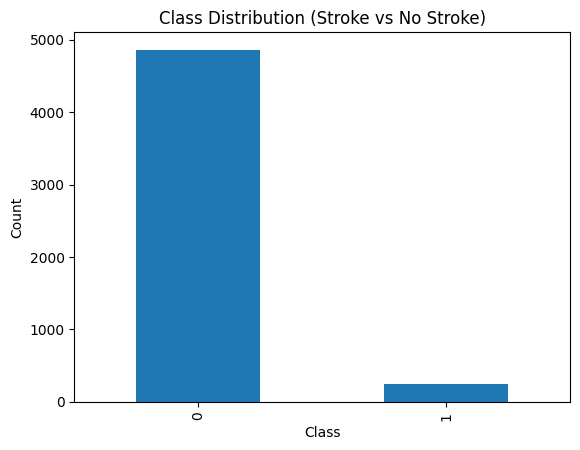

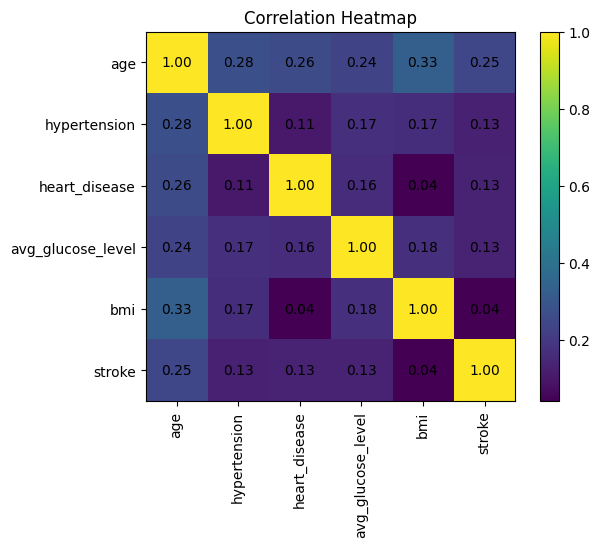


Logistic Regression
------------------------------
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022



<Figure size 640x480 with 0 Axes>

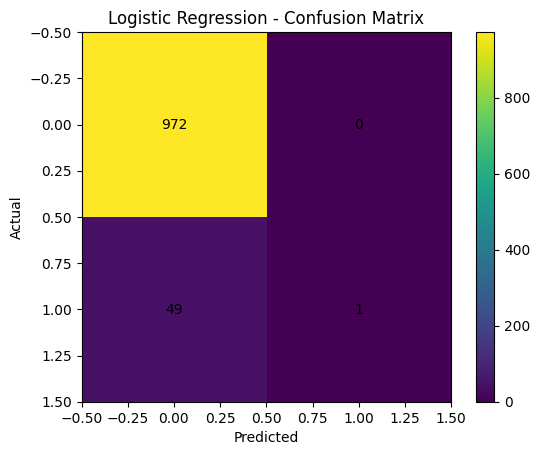


Decision Tree
------------------------------
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



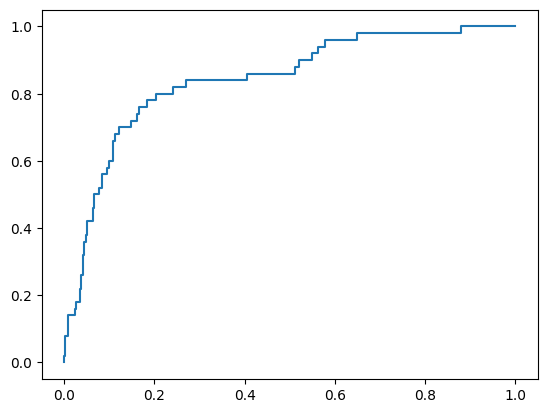

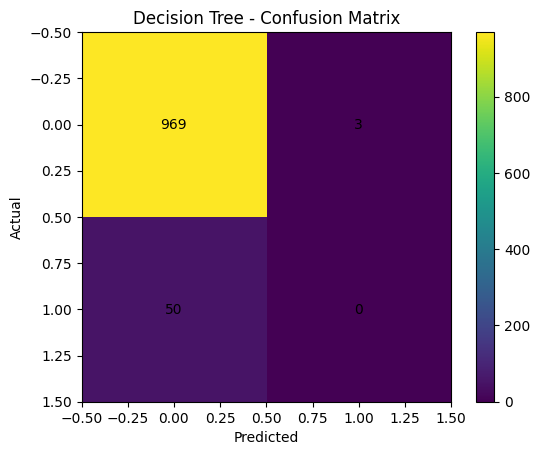


Random Forest
------------------------------
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.17      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.56      0.51      0.50      1022
weighted avg       0.91      0.95      0.93      1022



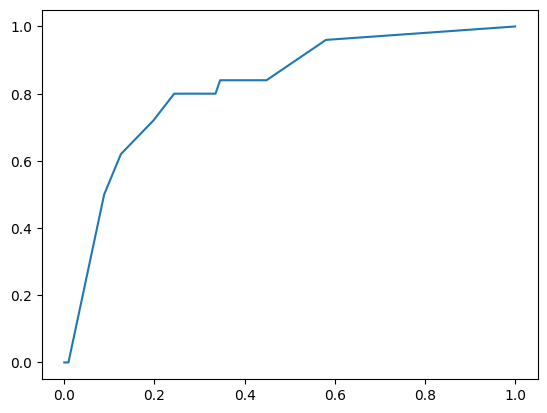

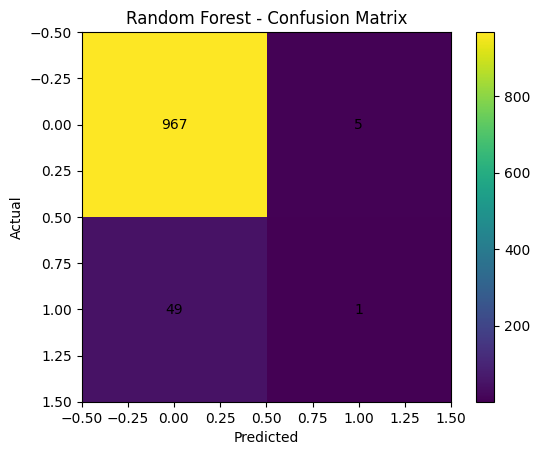

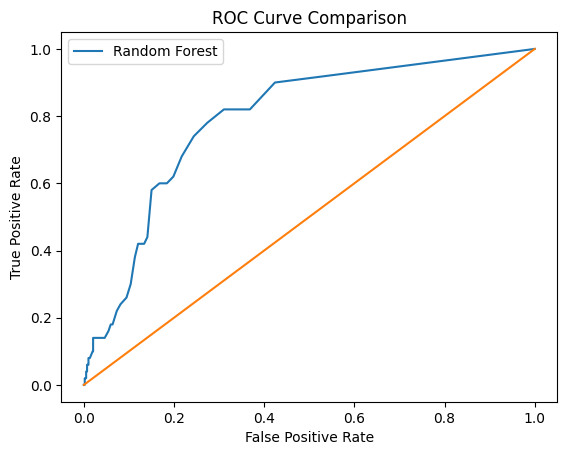


Model Comparison:
                 Model  Accuracy  F1 Score   ROC-AUC
0  Logistic Regression  0.952055  0.039216  0.842428
1        Decision Tree  0.948141  0.000000  0.821965
2        Random Forest  0.947162  0.035714  0.791440


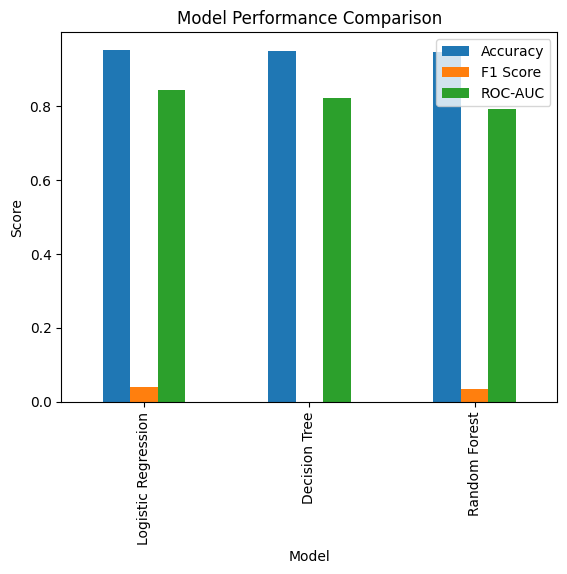

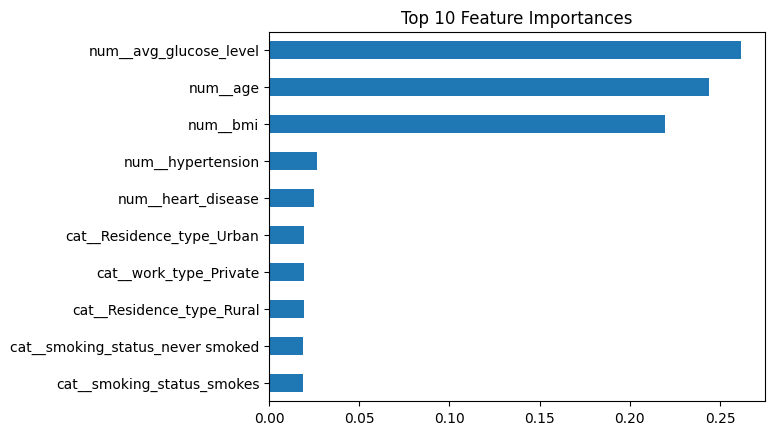

In [1]:

# STROKE PREDICTION 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)


# CREATE FOLDER FOR PLOTS

os.makedirs("plots", exist_ok=True)


# 1. LOAD DATA

df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df = df.drop(columns=["id"])


# 2. BASIC VISUALS


# Class distribution
plt.figure()
df["stroke"].value_counts().plot(kind="bar")
plt.title("Class Distribution (Stroke vs No Stroke)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.savefig("plots/class_distribution.png")
plt.show()

# Correlation heatmap (manual)
corr = df.select_dtypes(include=np.number).corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.savefig("plots/correlation_heatmap.png")
plt.show()


# 3. FEATURES & TARGET

X = df.drop("stroke", axis=1)
y = df["stroke"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns


# 4. PREPROCESSING

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


# 5. SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 6. MODELS
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

# ROC curve plot
plt.figure()

# -------------------------------
# 7. TRAIN + EVALUATE + VISUALS
# -------------------------------
for name, model in models.items():
    
    clf = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    
    results.append([name, acc, f1, roc])
    
    print(f"\n{name}")
    print("-" * 30)
    print(classification_report(y_test, y_pred))
    
    # -------------------------------
    # CONFUSION MATRIX
    # -------------------------------
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(f"{name} - Confusion Matrix")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(len(cm)):
        for j in range(len(cm)):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.savefig(f"plots/{name}_confusion_matrix.png")
    plt.show()
    
    # -------------------------------
    # ROC CURVE
    # -------------------------------
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=name)

# Final ROC comparison
plt.plot([0, 1], [0, 1])
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("plots/roc_curve_comparison.png")
plt.show()

# -------------------------------
# 8. RESULTS TABLE + BAR CHART
# -------------------------------
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score", "ROC-AUC"])
print("\nModel Comparison:")
print(results_df.sort_values(by="ROC-AUC", ascending=False))

# Bar chart
results_df.set_index("Model").plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.savefig("plots/model_performance.png")
plt.show()

# -------------------------------
# 9. FEATURE IMPORTANCE
# -------------------------------
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

encoded_features = rf_pipeline.named_steps["preprocessing"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

feat_imp = pd.Series(importances, index=encoded_features).sort_values(ascending=False)

plt.figure()
feat_imp.head(10).plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.savefig("plots/feature_importance.png")
plt.show()